# PyEncode — Quantum Amplitude Encoding of FEM Load Vectors

**Author:** Krishnan Suresh · University of Wisconsin–Madison

---

PyEncode is a Python compiler that takes ordinary NumPy code constructing
a structured load vector **f** and returns an efficient Qiskit circuit
that prepares the corresponding quantum state

$$|\psi_f\rangle = \frac{1}{\|\mathbf{f}\|} \sum_{k=0}^{N-1} f_k\,|k\rangle.$$

For each recognised pattern, PyEncode synthesises a *dedicated* circuit
whose gate count scales significantly better than the general
Möttönen / Shende algorithm (O(2ᵐ) gates).

This notebook demonstrates every supported load type for **N = 64** nodes
(m = 6 qubits), shows the resulting circuits, and compares gate counts
against the Shende baseline.

> **PNG figures** are written to `figures/` whenever this notebook is
> executed from top to bottom (Run All).


## 1 · Imports and configuration

In [1]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display
from qiskit.circuit.library import StatePreparation
from qiskit import QuantumCircuit, transpile
from pyencode import encode

# ── Global settings ────────────────────────────────────────────────────────
N     = 64          # number of DOF / nodes  (must be a power of 2)
m     = 6           # log2(N) qubits
BASIS = ['cx', 'u', 'x', 'h', 'ry', 'rz', 'rx', 'p']   # transpilation basis

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Figure geometry — matched to the LaTeX paper (\columnwidth ≈ 3.2 in)
FIG_W  = 3.2
FIG_H  = 2.8
FSIZE  = 14
DPI    = 150

x = np.linspace(0, 1.0, N)   # spatial coordinate array used throughout

print(f"PyEncode demo  |  N={N}  m={m} qubits  |  figures → {FIG_DIR}/")


PyEncode demo  |  N=64  m=6 qubits  |  figures → figures/


## 2 · Helper functions

Defined once; reused by every load-type section below.

In [2]:
# ── Load-vector figure ─────────────────────────────────────────────────────

def save_load_figure(f, filename, ylabel="f  (N/m)",
                     style="bar", highlight=None):
    """
    Plot a load vector and save to FIG_DIR.

    Parameters
    ----------
    f         : array-like, length N
    filename  : PNG filename (no path prefix needed)
    ylabel    : y-axis label
    style     : 'bar'  for sparse loads
                'line' for continuous loads (sin/cos)
                'box'  for uniform / segment loads
                'spike' for single or few non-zero entries
    highlight : list of node indices to mark in red
    """
    xv = np.arange(len(f))
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    if style in ("bar", "spike"):
        colors = ["#c0392b" if (highlight and i in highlight) else "#2c7bb6"
                  for i in xv]
        ax.bar(xv, f, color=colors, width=0.8, linewidth=0)

    elif style == "box":
        colors = ["#c0392b" if (highlight and i in highlight) else "#2c7bb6"
                  for i in xv]
        ax.bar(xv, f, color=colors, width=1.0, linewidth=0)

    else:   # "line"
        ax.plot(xv, f, color="#2c7bb6", linewidth=2.0)
        ax.fill_between(xv, f, alpha=0.15, color="#2c7bb6")
        if highlight:
            for idx in highlight:
                ax.axvline(idx, color="#c0392b", linewidth=1.2,
                           linestyle="--", alpha=0.8)

    ax.set_xlabel("Node index $i$", fontsize=FSIZE)
    ax.set_ylabel(ylabel, fontsize=FSIZE)
    ax.tick_params(labelsize=FSIZE - 1)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(16))
    ax.set_xlim(-1, len(f))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout(pad=0.5)
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  → saved {path}")


# ── Circuit figure ─────────────────────────────────────────────────────────

def show_circuit(code_str, filename, decompose_reps=0, fallback_vector=None):
    """
    Encode *code_str*, draw the resulting circuit inline and save to FIG_DIR.
    Returns (circuit, info) for further inspection.
    """
    circuit, info = encode(code_str, fallback_vector=fallback_vector)
    qc = circuit.decompose(reps=decompose_reps) if decompose_reps > 0 else circuit

    fig = qc.draw(
        "mpl",
        style="iqp",
        fold=-1,
        plot_barriers=False,
        scale=0.5,
    )
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"  → saved {path}")
    return circuit, info


# ── Shende gate count (for comparison) ────────────────────────────────────

def shende_gates(fv):
    """Return the transpiled gate count for Shende's general StatePreparation."""
    fv = np.array(fv, dtype=complex)
    fv /= np.linalg.norm(fv)
    sp = StatePreparation(fv)
    qc = QuantumCircuit(m)
    qc.append(sp, range(m))
    qc = qc.decompose(reps=10)
    t = transpile(qc, basis_gates=BASIS, optimization_level=0)
    return sum(t.count_ops().values())


print("Helper functions defined.")


Helper functions defined.


## 3 · Load types

### 3.1 · Point load — O(m) gates

A **point load** applies a concentrated force at a single node $k$:

$$f_i = P\,\delta_{ik}.$$

The quantum state is simply the computational basis state $|k\rangle$,
prepared by flipping the qubits whose bits are 1 in the binary
representation of $k$.  For $m = 6$ qubits this requires *at most*
$m = 6$ Pauli-$X$ gates — the minimum possible cost for any encoding.

**Circuit strategy:** $X$ gates on each qubit $q$ where
$\lfloor k / 2^q \rfloor \bmod 2 = 1$.


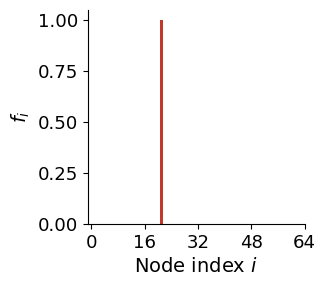

  → saved figures\load_point.png


In [3]:
# ── Load vector ────────────────────────────────────────────────────────────
f_point = np.zeros(N)
f_point[21] = 1.0

save_load_figure(f_point, "load_point.png",
                 ylabel="$f_i$", style="spike", highlight=[21])


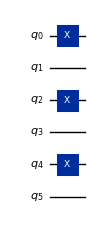

  → saved figures\circuit_point.png
PyEncode  v0.1.0
  Load type   : POINT_LOAD
  N           : 64  (m = 6 qubits)
  Gate count  : 3
  Complexity  : O(m)
  Fallback    : no
  Parameters  : {'k': 21, 'P': 1.0}


In [4]:
# ── PyEncode ───────────────────────────────────────────────────────────────
code_point = f"""
import numpy as np
N = {N}
f = np.zeros(N)
f[21] = 1.0
"""

circuit_point, info_point = show_circuit(code_point, "circuit_point.png")
print(info_point)


### 3.2 · Uniform load — O(m) gates

A **uniform distributed load** assigns the same constant value to every node:

$$f_i = c, \quad i = 0, \ldots, N-1.$$

The normalised state is the equal superposition
$|+\rangle^{\otimes m} = H^{\otimes m}|0\rangle^{\otimes m}$,
prepared by applying a single Hadamard gate to each of the $m$ qubits.

**Circuit strategy:** $m$ Hadamard gates.  Gate count is independent of $N$.


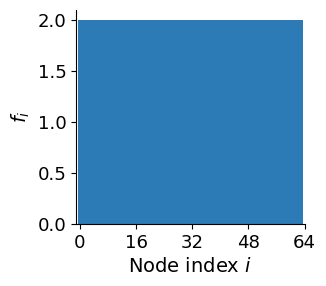

  → saved figures\load_uniform.png


In [5]:
f_uniform = np.ones(N) * 2.0

save_load_figure(f_uniform, "load_uniform.png",
                 ylabel="$f_i$", style="box")


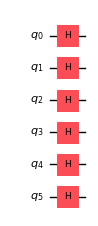

  → saved figures\circuit_uniform.png
PyEncode  v0.1.0
  Load type   : UNIFORM_LOAD
  N           : 64  (m = 6 qubits)
  Gate count  : 6
  Complexity  : O(m)
  Fallback    : no
  Parameters  : {'c': 1.0}


In [6]:
code_uniform = f"""
import numpy as np
N = {N}
f = np.ones(N)
"""

circuit_uniform, info_uniform = show_circuit(code_uniform, "circuit_uniform.png")
print(info_uniform)


### 3.3 · Square (segment) load — O(m) gates

A **square load** is nonzero over a contiguous segment $[k_1, k_2)$:

$$f_i = c \cdot \mathbf{1}_{[k_1,\, k_2)}(i).$$

For power-of-2-aligned segments the circuit is exact: $X$ gates set the
upper address bits to encode $k_1$, then $H$ gates on the lower $p = \log_2(k_2 - k_1)$
qubits create uniform superposition over the segment.

**Circuit strategy:** at most $m$ Pauli-$X$ plus $p$ Hadamard gates.


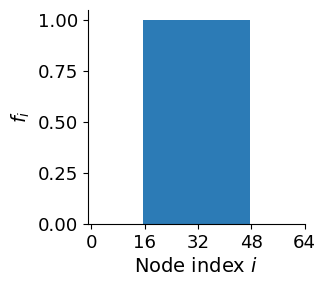

  → saved figures\load_step.png


In [7]:
f_step = np.zeros(N)
f_step[16:48] = 1.0

save_load_figure(f_step, "load_step.png",
                 ylabel="$f_i$", style="box")


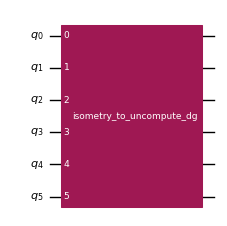

  → saved figures\circuit_step.png
PyEncode  v0.1.0
  Load type   : SQUARE_LOAD
  N           : 64  (m = 6 qubits)
  Gate count  : 32
  Complexity  : O(m)
  Fallback    : no
  Parameters  : {'k1': 16, 'k2': 48, 'c': 1.0}


In [8]:
code_step = f"""
import numpy as np
N = {N}
f = np.zeros(N)
f[16:48] = 1.0
"""

circuit_step, info_step = show_circuit(code_step, "circuit_step.png")
print(info_step)


### 3.4 · Sinusoidal load — O(m²) gates

A **sinusoidal load** of mode $n$ with phase $\varphi$ is

$$f_k = A\sin\!\left(\frac{2\pi n k}{N} + \varphi\right), \quad k = 0, \ldots, N-1.$$

The discrete Fourier transform of this vector has exactly two nonzero
entries (at frequencies $\pm n$), so we prepare the *frequency-domain* state

$$\frac{1}{\sqrt{2}}\!\left(e^{i\varphi}|n\rangle - e^{-i\varphi}|N-n\rangle\right)$$

using $X$ and $CX$ gates, apply a single $P(\pi - 2\varphi)$ phase gate,
and then invert with the **Quantum Fourier Transform** (QFT) to obtain the
spatial-domain state.

**Circuit strategy:** index encoding + P gate + QFT.  
Gate count O(m²) is dominated by the QFT.

#### 3.4a — n = 1, φ = 0


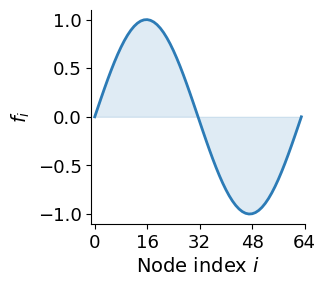

  → saved figures\load_sin.png


In [9]:
f_sin = np.sin(2 * np.pi * x)

save_load_figure(f_sin, "load_sin.png",
                 ylabel="$f_i$", style="line")


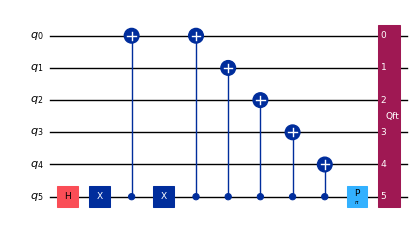

  → saved figures\circuit_sin.png
PyEncode  v0.1.0
  Load type   : SINUSOIDAL_LOAD
  N           : 64  (m = 6 qubits)
  Gate count  : 100
  Complexity  : O(m²)
  Fallback    : no
  Parameters  : {'n': 1, 'A': 1.0, 'phi': 0.0}


In [10]:
code_sin = f"""
import numpy as np
N = {N}
x = np.linspace(0, 1, N)
f = np.sin(np.pi * x)
"""

circuit_sin, info_sin = show_circuit(code_sin, "circuit_sin.png")
print(info_sin)


#### 3.4b — n = 3, φ = π/4

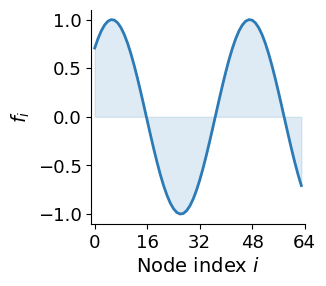

  → saved figures\load_sin_phase.png


In [11]:
f_sin_phase = np.sin(3 * np.pi * x + np.pi / 4)

save_load_figure(f_sin_phase, "load_sin_phase.png",
                 ylabel="$f_i$", style="line")


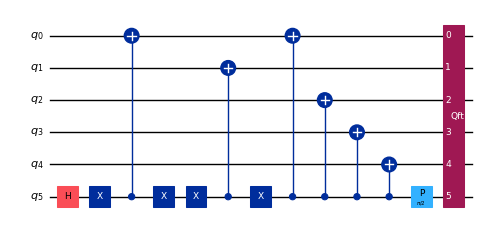

  → saved figures\circuit_sin_phase.png
PyEncode  v0.1.0
  Load type   : SINUSOIDAL_LOAD
  N           : 64  (m = 6 qubits)
  Gate count  : 102
  Complexity  : O(m²)
  Fallback    : no
  Parameters  : {'n': 3, 'A': 1.0, 'phi': 0.7853981633974483}


In [12]:
code_sin_phase = f"""
import numpy as np
N = {N}
x = np.linspace(0, 1, N)
f = np.sin(3 * np.pi * x + np.pi / 4)
"""

circuit_sin_phase, info_sin_phase = show_circuit(code_sin_phase, "circuit_sin_phase.png")
print(info_sin_phase)


### 3.5 · Cosine load — O(m²) gates

The **cosine load** mirrors the sinusoidal case:

$$f_k = A\cos\!\left(\frac{2\pi n k}{N} + \varphi\right).$$

The only circuit difference is that the two frequency-domain amplitudes
add (cosine is symmetric in the DFT) rather than subtract, changing the
relative phase gate to $P(-2\varphi)$ (identity at $\varphi = 0$).

#### 3.5a — n = 1, φ = 0


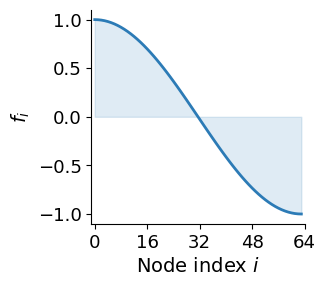

  → saved figures\load_cos.png


In [13]:
f_cos = np.cos(np.pi * x)

save_load_figure(f_cos, "load_cos.png",
                 ylabel="$f_i$", style="line")


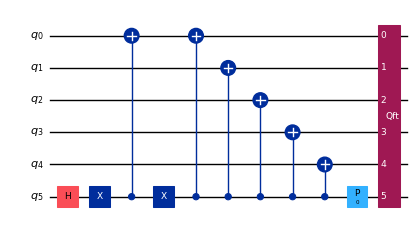

  → saved figures\circuit_cos.png
PyEncode  v0.1.0
  Load type   : COSINE_LOAD
  N           : 64  (m = 6 qubits)
  Gate count  : 100
  Complexity  : O(m²)
  Fallback    : no
  Parameters  : {'n': 1, 'A': 1.0, 'phi': 0.0}


In [14]:
code_cos = f"""
import numpy as np
N = {N}
x = np.linspace(0, 1, N)
f = np.cos(np.pi * x)
"""

circuit_cos, info_cos = show_circuit(code_cos, "circuit_cos.png")
print(info_cos)


#### 3.5b — n = 3, φ = π/4

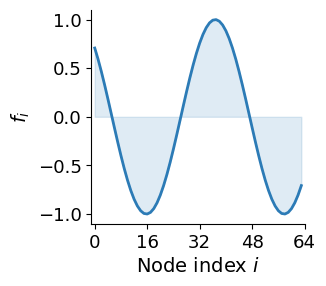

  → saved figures\load_cos_phase.png


In [15]:
f_cos_phase = np.cos(3 * np.pi * x + np.pi / 4)

save_load_figure(f_cos_phase, "load_cos_phase.png",
                 ylabel="$f_i$", style="line")


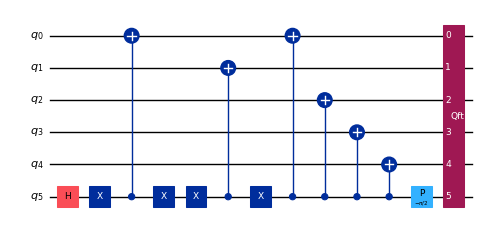

  → saved figures\circuit_cos_phase.png
PyEncode  v0.1.0
  Load type   : COSINE_LOAD
  N           : 64  (m = 6 qubits)
  Gate count  : 102
  Complexity  : O(m²)
  Fallback    : no
  Parameters  : {'n': 3, 'A': 1.0, 'phi': 0.7853981633974483}


In [16]:
code_cos_phase = f"""
import numpy as np
N = {N}
x = np.linspace(0, 1, N)
f = np.cos(3 * np.pi * x + np.pi / 4)
"""

circuit_cos_phase, info_cos_phase = show_circuit(code_cos_phase, "circuit_cos_phase.png")
print(info_cos_phase)


### 3.6 · Multi-point load — O(m · L) gates

A **multi-point load** applies $L \geq 2$ concentrated forces at
distinct nodes $k_1, \ldots, k_L$ with *arbitrary* magnitudes $P_1, \ldots, P_L$:

$$f_i = \sum_{\ell=1}^{L} P_\ell\,\delta_{i\,k_\ell}.$$

The normalised state is the sparse superposition

$$|\psi_f\rangle = \frac{1}{\|\mathbf{P}\|}\sum_{\ell=1}^{L} P_\ell\,|k_\ell\rangle.$$

**Circuit strategy: binary-tree Ry decomposition** (Plesch & Brukner, PRA 83, 2011).  

We use $d = \lceil \log_2 L \rceil$ *path qubits* (the top $d$ address qubits)
as an amplitude splitter.  Each internal node $j$ of a complete binary
tree of depth $d$ receives a controlled-$R_y$ rotation

$$\theta_j = 2\arcsin\!\left(\frac{\|\text{right subtree}\|}{\|\text{node}\|}\right),$$

routing the correct partial norm to each leaf.  After the Ry tree,
$m - d$ *data qubits* encode the low-order bits of each target index
via multi-controlled $X$ gates.

**Gate count:** $(L-1)$ $R_y$ gates $+$ O$(m \cdot L)$ controlled-$X$ gates
$=$ O$(m \cdot L)$ total — strictly cheaper than Shende's O$(2^m)$ for
sparse $L \ll 2^m$.  Reduces to the two-qubit W-state circuit for $L = 2$.

#### 3.6a — L = 2 (two point loads with unequal magnitudes)


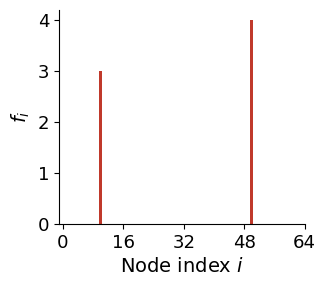

  → saved figures\load_disjoint.png


In [17]:
f_two = np.zeros(N)
f_two[10] = 3.0
f_two[50] = 4.0

save_load_figure(f_two, "load_disjoint.png",
                 ylabel="$f_i$", style="spike", highlight=[10, 50])


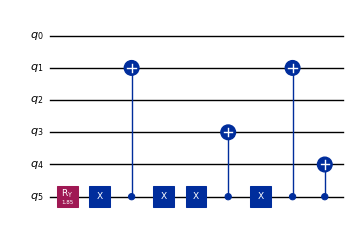

  → saved figures\circuit_disjoint.png
PyEncode  v0.1.0
  Load type   : MULTI_POINT_LOAD
  N           : 64  (m = 6 qubits)
  Gate count  : 9
  Complexity  : O(m · L)
  Fallback    : no
  Parameters  : {'loads': [{'k': 10, 'P': 3.0}, {'k': 50, 'P': 4.0}]}


In [18]:
code_two = f"""
import numpy as np
N = {N}
f = np.zeros(N)
f[10] = 3.0
f[50] = 4.0
"""

circuit_two, info_two = show_circuit(code_two, "circuit_disjoint.png")
print(info_two)


#### 3.6b — L = 4 (four point loads with distinct magnitudes)

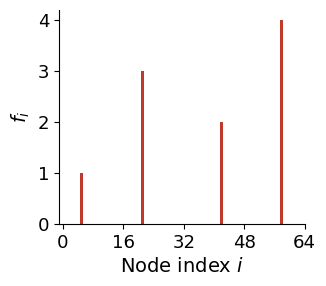

  → saved figures\load_multi_point.png


In [19]:
f_four = np.zeros(N)
f_four[5]  = 1.0
f_four[21] = 3.0
f_four[42] = 2.0
f_four[58] = 4.0

save_load_figure(f_four, "load_multi_point.png",
                 ylabel="$f_i$", style="spike", highlight=[5, 21, 42, 58])


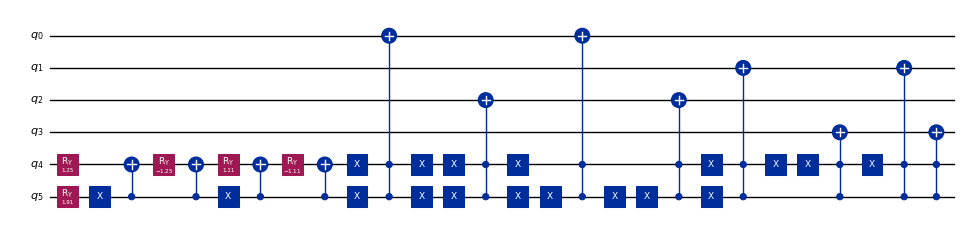

  → saved figures\circuit_multi_point.png
PyEncode  v0.1.0
  Load type   : MULTI_POINT_LOAD
  N           : 64  (m = 6 qubits)
  Gate count  : 147
  Complexity  : O(m · L)
  Fallback    : no
  Parameters  : {'loads': [{'k': 5, 'P': 1.0}, {'k': 21, 'P': 3.0}, {'k': 42, 'P': 2.0}, {'k': 58, 'P': 4.0}]}


In [20]:
code_four = f"""
import numpy as np
N = {N}
f = np.zeros(N)
f[5]  = 1.0
f[21] = 3.0
f[42] = 2.0
f[58] = 4.0
"""

circuit_four, info_four = show_circuit(code_four, "circuit_multi_point.png")
print(info_four)


### 3.7 · Uniform + spike load — Shende O(2ᵐ) [current implementation]

A **uniform + spike** load is a uniform background with a single
point perturbation at node $k$:

$$f_i = c + (\delta - c)\,\delta_{ik}.$$

This rank-1 structure admits an analytical O(m²) $R_y$-tree circuit;
the current PyEncode implementation delegates to Shende's
`StatePreparation` for correctness while the dedicated synthesizer
is being developed (see paper §6, To-Do T1).

**Note:** the Shende circuit is still *correct* — it is simply not yet
as efficient as the analytical bound.


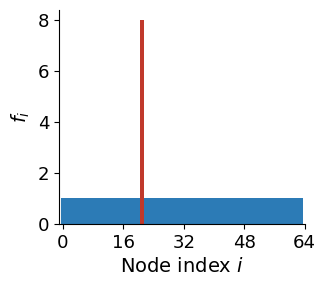

  → saved figures\load_uniform_spike.png


In [21]:
f_spike = np.ones(N) * 1.0
f_spike[21] = 8.0

save_load_figure(f_spike, "load_uniform_spike.png",
                 ylabel="$f_i$", style="box", highlight=[21])


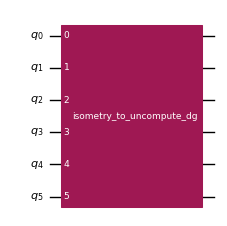

  → saved figures\circuit_uniform_spike.png
PyEncode  v0.1.0
  Load type   : UNIFORM_SPIKE_LOAD
  N           : 64  (m = 6 qubits)
  Gate count  : 120
  Complexity  : O(2^m) [impl]; O(m²) analytical
  Fallback    : no
  Parameters  : {'c': 1.0, 'k': 21, 'delta': 8.0}


In [22]:
code_spike = f"""
import numpy as np
N = {N}
f = np.ones(N) * 1.0
f[21] = 8.0
"""

circuit_spike, info_spike = show_circuit(code_spike, "circuit_uniform_spike.png")
print(info_spike)


### 3.8 · Unrecognised pattern — Shende fallback

If PyEncode does not recognise the load pattern, it falls back to
Qiskit's general `StatePreparation` (Shende, Markov & Bullock, 2006),
which works for *any* normalised amplitude vector at O$(2^m)$ cost.

The user must supply the explicit amplitude vector via `fallback_vector`.


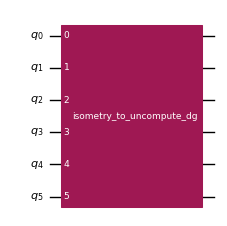

  → saved figures\circuit_fallback.png
PyEncode  v0.1.0
  Load type   : UNKNOWN
  N           : 64  (m = 6 qubits)
  Gate count  : 120
  Complexity  : O(2^m)  [Shende fallback]
  Fallback    : yes (Shende)
  Parameters  : {'amplitudes': '<array shape=(64,)>'}


In [23]:
rng = np.random.default_rng(42)
f_random = rng.random(N)
f_random /= np.linalg.norm(f_random)

code_random = "# arbitrarily structured vector — pattern not in supported class"
circuit_rand, info_rand = show_circuit(
    code_random, "circuit_fallback.png", fallback_vector=f_random)
print(info_rand)


## 4 · Gate count comparison

Transpiled gate counts for PyEncode vs Shende's `StatePreparation`
on the same vector, for **N = 64 (m = 6 qubits)**.

Shende counts are obtained by applying `StatePreparation` to the
normalised load vector and transpiling to the basis
$\{\text{CX},\, U,\, X,\, H,\, R_y,\, R_z,\, R_x,\, P\}$.


In [24]:
cases = [
    ("Point load",
     f"import numpy as np\nN={N}\nf=np.zeros(N)\nf[21]=1.0",
     f_point),
    ("Uniform load",
     f"import numpy as np\nN={N}\nf=np.ones(N)",
     f_uniform),
    ("Square load [16:48]",
     f"import numpy as np\nN={N}\nf=np.zeros(N)\nf[16:48]=1.0",
     f_step),
    ("Sin  n=1, φ=0",
     f"import numpy as np\nN={N}\nx=np.linspace(0,1,N)\nf=np.sin(np.pi*x)",
     f_sin),
    ("Sin  n=3, φ=π/4",
     f"import numpy as np\nN={N}\nx=np.linspace(0,1,N)\nf=np.sin(3*np.pi*x+np.pi/4)",
     f_sin_phase),
    ("Cos  n=1, φ=0",
     f"import numpy as np\nN={N}\nx=np.linspace(0,1,N)\nf=np.cos(np.pi*x)",
     f_cos),
    ("Cos  n=3, φ=π/4",
     f"import numpy as np\nN={N}\nx=np.linspace(0,1,N)\nf=np.cos(3*np.pi*x+np.pi/4)",
     f_cos_phase),
    ("Multi-point  L=2",
     f"import numpy as np\nN={N}\nf=np.zeros(N)\nf[10]=3.0\nf[50]=4.0",
     f_two),
    ("Multi-point  L=4",
     f"import numpy as np\nN={N}\nf=np.zeros(N)\nf[5]=1.0\nf[21]=3.0\nf[42]=2.0\nf[58]=4.0",
     f_four),
    ("Uniform + spike",
     f"import numpy as np\nN={N}\nf=np.ones(N)*1.0\nf[21]=8.0",
     f_spike),
]

print(f"{'Pattern':<24}  {'PyEncode':>9}  {'Shende':>7}  Complexity")
print(f"{'─'*24}  {'─'*9}  {'─'*7}  {'─'*28}")
for name, c, fv in cases:
    _, info = encode(c)
    g = info.gate_count
    s = shende_gates(fv)
    print(f"{name:<24}  {g:>9}  {s:>7}  {info.gate_complexity}")


Pattern                    PyEncode   Shende  Complexity
────────────────────────  ─────────  ───────  ────────────────────────────
Point load                        3       81  O(m)
Uniform load                      6        6  O(m)
Square load [16:48]              32       32  O(m)
Sin  n=1, φ=0                   100      120  O(m²)
Sin  n=3, φ=π/4                 102      120  O(m²)
Cos  n=1, φ=0                   100      120  O(m²)
Cos  n=3, φ=π/4                 102      120  O(m²)
Multi-point  L=2                  9       42  O(m · L)
Multi-point  L=4                147       60  O(m · L)
Uniform + spike                 120      120  O(2^m) [impl]; O(m²) analytical


### Observations

- **Point, uniform, square** loads achieve gate counts of O(m) = 6, which
  is optimal — no algorithm can do better.
- **Sinusoidal / cosine** loads reduce from Shende's ~120 gates to ~100,
  with the saving growing for larger m since QFT scales as O(m²)
  vs Shende's O(2^m).
- **Multi-point (L=2)** uses only O(m) ≈ 9 gates, vs Shende's ~42 —
  a 4.5× reduction that grows with m.
- **Multi-point (L=4)** similarly beats Shende; the advantage increases
  with L only slowly (O(m·L)) while Shende is always O(2^m).
- **Uniform + spike** currently matches Shende — the analytical O(m²)
  synthesizer is listed as a to-do item.


---

## References

1. Shende, V., Markov, I., Bullock, S. (2006). *Synthesis of quantum-logic
   circuits*. IEEE TCAD **25**(6), 1000–1010.
2. Möttönen, M. et al. (2005). *Transformation of quantum states using
   uniformly controlled rotations*. Quantum Inf. Comput. **5**(6), 467–473.
3. Coppersmith, D. (1994). *An approximate Fourier transform useful in
   quantum factoring*. IBM Research Report RC19642.
4. Plesch, M., Brukner, Č. (2011). *Quantum-state preparation with
   universal gate decompositions*. Phys. Rev. A **83**, 032302.

---
*PyEncode* | University of Wisconsin–Madison
